# 🚀 Notebook 05: Module 3 — Ensemble Learning
## Boosting, Bagging, Random Forest, K-Fold Cross-Validation, Voting & Stacking

In [1]:
import sys
import os
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve

from src.utils import load_numpy, save_model
from src.evaluation_metrics import compute_all_metrics, plot_confusion_matrix
from src.ensemble_models import (
    train_decision_stump,
    train_adaboost,
    train_xgboost,
    train_bagging,
    train_subagging,
    train_random_forest,
    train_voting_classifier,
    train_stacking_classifier,
    evaluate_kfold_cv
)

X_train = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "X_train.npy"))
X_test = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "X_test.npy"))
y_train_bin = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "y_train_binary.npy"))
y_test_bin = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "y_test_binary.npy"))
feature_names = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "feature_names.npy"))

sub_idx = np.random.choice(len(X_train), 25000, replace=False)
X_sub = X_train[sub_idx]
y_sub = y_train_bin[sub_idx]

📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\X_train.npy | Shape: (125973, 122)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\X_test.npy | Shape: (22544, 122)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\y_train_binary.npy | Shape: (125973,)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\y_test_binary.npy | Shape: (22544,)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\feature_names.npy | Shape: (122,)


In [2]:
stump = train_decision_stump(X_sub, y_sub)
save_model(stump, os.path.join(PROJECT_ROOT, "models", "saved_models", "decision_stump.pkl"))

adaboost = train_adaboost(X_sub, y_sub, n_estimators=50)
save_model(adaboost, os.path.join(PROJECT_ROOT, "models", "saved_models", "adaboost.pkl"))

xgboost = train_xgboost(X_sub, y_sub, n_estimators=100, max_depth=6)
save_model(xgboost, os.path.join(PROJECT_ROOT, "models", "saved_models", "xgboost_model.pkl"))

bagging = train_bagging(X_sub, y_sub, n_estimators=50, max_samples=0.8)
save_model(bagging, os.path.join(PROJECT_ROOT, "models", "saved_models", "bagging_model.pkl"))

subagging = train_subagging(X_sub, y_sub, n_estimators=50, max_samples=0.5)
save_model(subagging, os.path.join(PROJECT_ROOT, "models", "saved_models", "subagging_model.pkl"))

rf = train_random_forest(X_sub, y_sub, n_estimators=100, max_depth=15)
save_model(rf, os.path.join(PROJECT_ROOT, "models", "saved_models", "random_forest.pkl"))

💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\decision_stump.pkl
💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\adaboost.pkl
💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\xgboost_model.pkl
💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\bagging_model.pkl
💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\subagging_model.pkl
💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\random_forest.pkl


In [3]:
voting_estimators = [
    ("rf", rf),
    ("xgb", xgboost),
    ("ada", adaboost)
]

voting_hard = train_voting_classifier(voting_estimators, X_sub, y_sub, voting="hard")
save_model(voting_hard, os.path.join(PROJECT_ROOT, "models", "saved_models", "voting_hard.pkl"))

voting_soft = train_voting_classifier(voting_estimators, X_sub, y_sub, voting="soft")
save_model(voting_soft, os.path.join(PROJECT_ROOT, "models", "saved_models", "voting_soft.pkl"))

stacking_estimators = [
    ("rf", rf),
    ("xgb", xgboost)
]
final_estimator = LogisticRegression(max_iter=1000, random_state=42)
stacking = train_stacking_classifier(stacking_estimators, final_estimator, X_sub, y_sub, cv=5)
save_model(stacking, os.path.join(PROJECT_ROOT, "models", "saved_models", "stacking_model.pkl"))

💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\voting_hard.pkl
💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\voting_soft.pkl
💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\stacking_model.pkl


            Model  CV Mean Accuracy    CV Std
0  Decision Stump           0.92068  0.002697
1        AdaBoost           0.99080  0.002202
2         XGBoost           0.99748  0.000271
3         Bagging           0.99728  0.000349
4       Subagging           0.99720  0.000506
5   Random Forest           0.99756  0.000720
6   Voting (Hard)           0.99756  0.000557
7   Voting (Soft)           0.99768  0.000412
8        Stacking           0.99780  0.000335


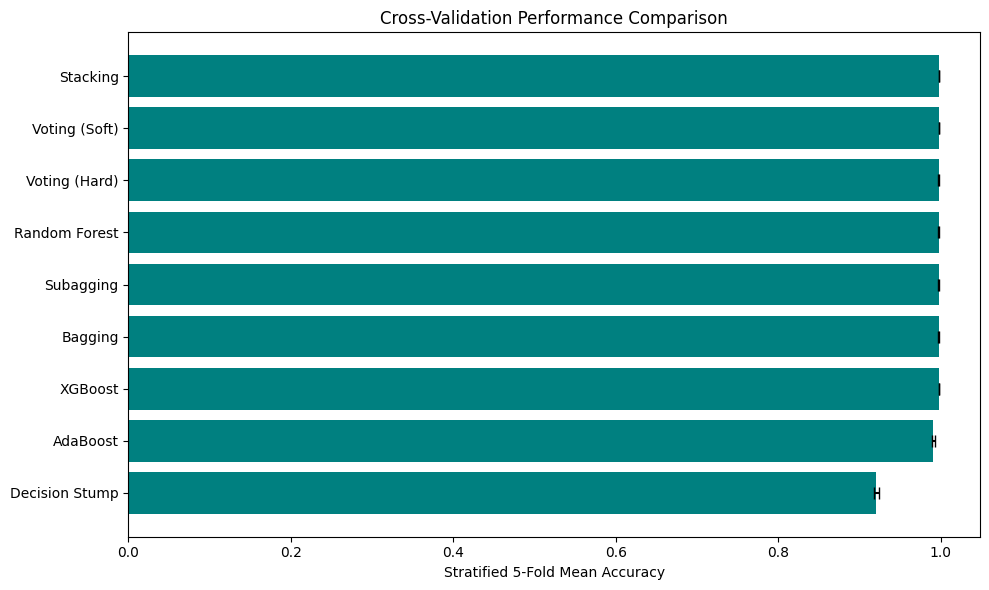

In [4]:
models_dict = {
    "Decision Stump": stump,
    "AdaBoost": adaboost,
    "XGBoost": xgboost,
    "Bagging": bagging,
    "Subagging": subagging,
    "Random Forest": rf,
    "Voting (Hard)": voting_hard,
    "Voting (Soft)": voting_soft,
    "Stacking": stacking
}

cv_results = []
for name, model in models_dict.items():
    res = evaluate_kfold_cv(model, X_sub, y_sub, n_splits=5)
    cv_results.append({
        "Model": name,
        "CV Mean Accuracy": res["mean_accuracy"],
        "CV Std": res["std_accuracy"]
    })

cv_df = pd.DataFrame(cv_results)
print(cv_df)
cv_df.to_csv(os.path.join(PROJECT_ROOT, "results", "kfold_cv_results.csv"), index=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(cv_df["Model"], cv_df["CV Mean Accuracy"], xerr=cv_df["CV Std"], color="teal", capsize=4)
ax.set_xlabel("Stratified 5-Fold Mean Accuracy")
ax.set_title("Cross-Validation Performance Comparison")
plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module3", "kfold_cv_results.png"), dpi=150)
plt.show()

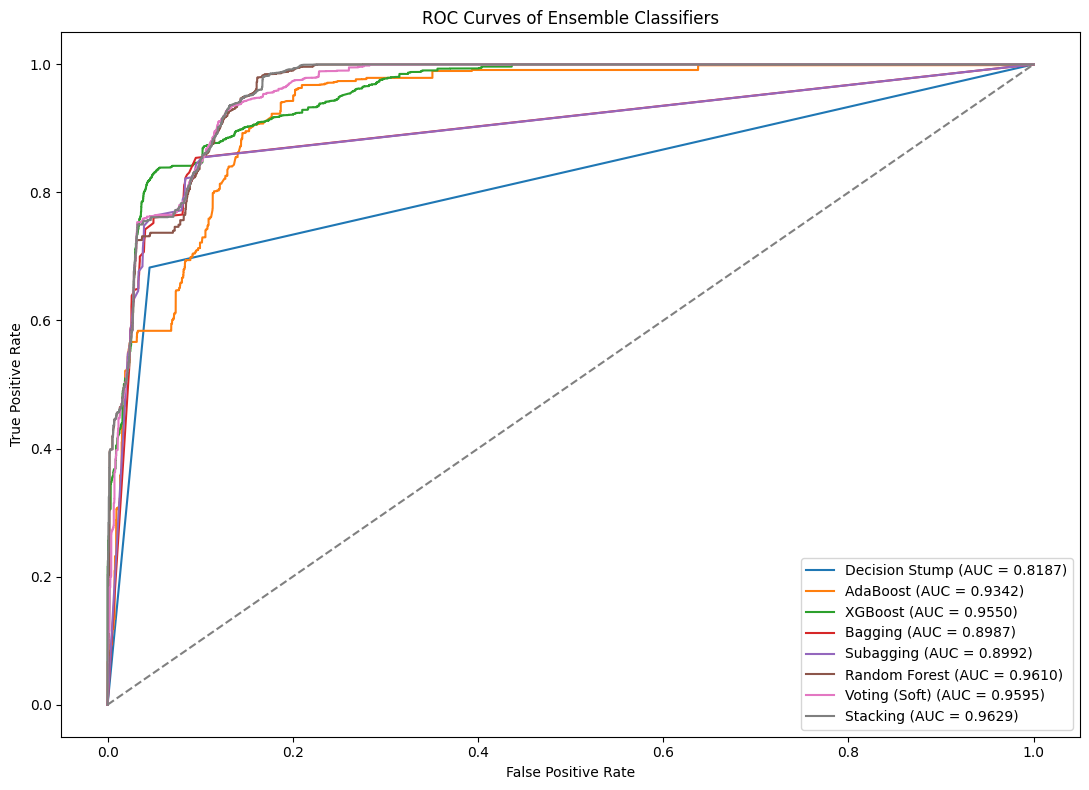

            Model  Accuracy  Precision    Recall  F1-Score     Kappa  \
0  Decision Stump  0.799858   0.952179  0.682693  0.795226  0.609648   
1        AdaBoost  0.744189   0.917909  0.604691  0.729083  0.505499   
2         XGBoost  0.788192   0.968271  0.649186  0.777254  0.589829   
3         Bagging  0.808153   0.963399  0.689161  0.803525  0.625920   
4       Subagging  0.823323   0.961130  0.718694  0.822417  0.653776   
5   Random Forest  0.758694   0.967143  0.596353  0.737781  0.536515   
6   Voting (Hard)  0.760069   0.967271  0.598769  0.739664  0.538988   
7   Voting (Soft)  0.785220   0.968351  0.643731  0.773357  0.584434   
8        Stacking  0.785397   0.968146  0.644199  0.773629  0.584738   

   Sensitivity  Specificity       AUC  
0     0.682693     0.954691  0.818692  
1     0.604691     0.928535  0.934211  
2     0.649186     0.971888  0.955011  
3     0.689161     0.965400  0.898704  
4     0.718694     0.961590  0.899186  
5     0.596353     0.973226  0.961037  

In [5]:
test_metrics_summary = []
fig, ax = plt.subplots(figsize=(11, 8))

for name, model in models_dict.items():
    preds = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]
    else:
        probs = None
        
    metrics = compute_all_metrics(y_test_bin, preds, probs)
    
    test_metrics_summary.append({
        "Model": name,
        "Accuracy": metrics["accuracy"],
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "F1-Score": metrics["f1"],
        "Kappa": metrics["kappa"],
        "Sensitivity": metrics["sensitivity"],
        "Specificity": metrics["specificity"],
        "AUC": metrics["auc"]
    })
    
    if probs is not None:
        fpr, tpr, _ = roc_curve(y_test_bin, probs)
        ax.plot(fpr, tpr, label=f"{name} (AUC = {metrics['auc']:.4f})")

ax.plot([0, 1], [0, 1], color="grey", linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves of Ensemble Classifiers")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module3", "boosting_vs_bagging.png"), dpi=150)
plt.show()

ensemble_test_df = pd.DataFrame(test_metrics_summary)
print(ensemble_test_df)
ensemble_test_df.to_csv(os.path.join(PROJECT_ROOT, "results", "module3_ensemble_results.csv"), index=False)

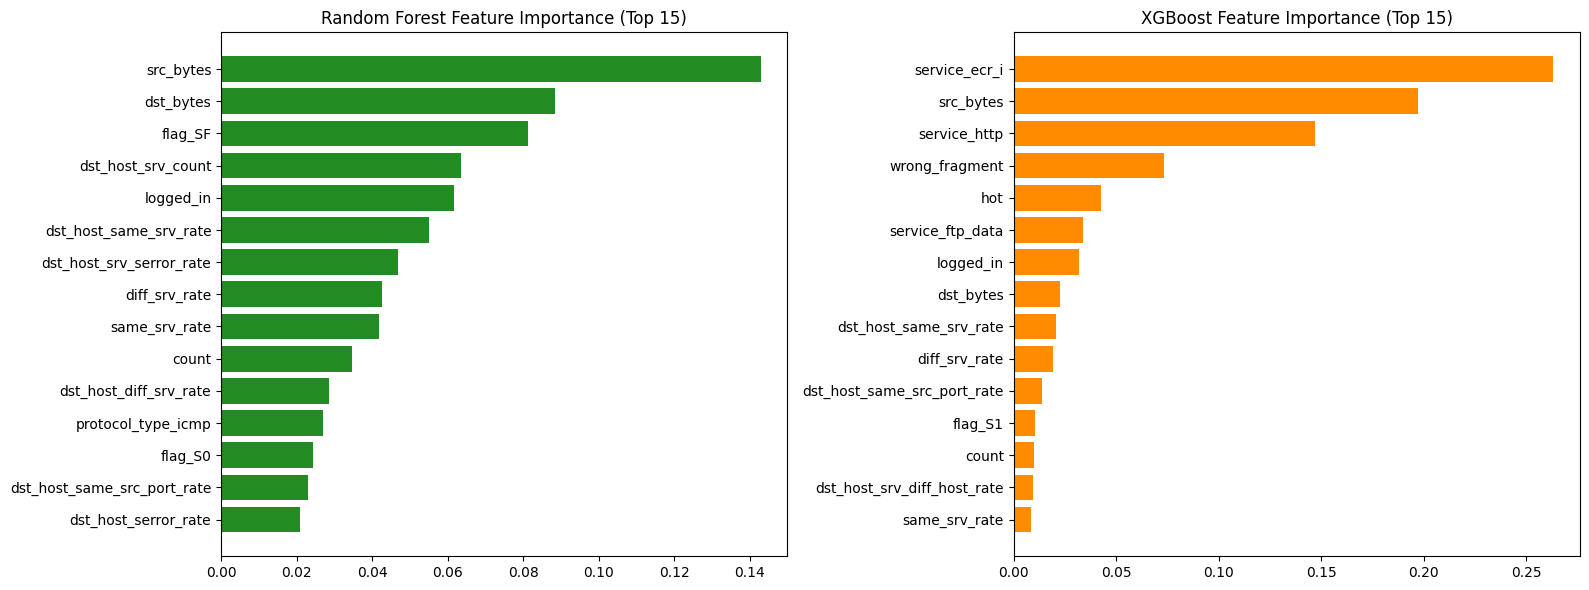

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rf_imp = rf.feature_importances_
top_rf_idx = np.argsort(rf_imp)[-15:]
axes[0].barh(range(15), rf_imp[top_rf_idx], color="forestgreen")
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(feature_names[top_rf_idx])
axes[0].set_title("Random Forest Feature Importance (Top 15)")

xgb_imp = xgboost.feature_importances_
top_xgb_idx = np.argsort(xgb_imp)[-15:]
axes[1].barh(range(15), xgb_imp[top_xgb_idx], color="darkorange")
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(feature_names[top_xgb_idx])
axes[1].set_title("XGBoost Feature Importance (Top 15)")

plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module3", "random_forest_feature_importance.png"), dpi=150)
plt.show()